here's an awkward fact about the previous two chapters: black holes are invisible.

i'm not being metphorical here. literally, a bare black hole emits nothing, reflects nothing and is small beyond reason — chapter one's entire event horizon, for a stellar-mass hole, would fit inside a city. if black holes were tidy eaters, we would probably still be arguing about whether they exist.

luckily, they are the messiest eaters in the universe.

so this chapter is about the mess. the accretion disk - what it is, why it exists, why it glows, and how to photograph it. by the end we'll have rendered the full anatomy: the lensed arcs, the photon ring, the shadow. this part always got me in uni, so please give me feedback for improvement!

(we're going back to the non-spinning schwarzschild hole for this one, to keep the maths friendly. everything here generalizes to kerr, and chapter two is sitting right there when we want it)

a question i always had was, why is there a disk at all?

a natural first guess is that stuff near a black hole just... falls in. straight down, like a rock off a cliff.

but almost nothing in the universe is aimed straight at anything. gas clouds, stripped stars all arrive with angular momentum and chapter one covers exactly what angular momentum does near a black hole, it puts a centrifugal barrier between you and the horizon. you don't fall in- you orbit.

i think a helpful way to visulaise this is the earlier drain analogy? water doesn't plummet down a drain either. it circles, crowds inward and forms a swirling sheet. in the case of our black hole, collisions flatten the infalling matter into a thin spinning disk, and then something cool happens,

friction.

adjacent rings of the disk orbit at different speeds (inner rings faster because kepler says so), so they rub against each other. the rubbing does two jobs at once,
* it bleeds away angular momentum, letting matter drift slowly inward, ring by ring, toward chapter one's last parking spot at $r = 6M$ and then over the edge
* it converts orbital energy into insane amounts of heat. the inner disk reaches millions of degrees and glows in x-rays

that is,

> the black hole does not shine. the disk lights itself.

every photon in our render will be gravitational potential energy, cashed out as heat by friction, on the way down. the black hole's only contribution is the plumbing.

now, how do we image this>

firing photons off the disk and hoping some fly into our camera is a lottery - almost all of them miss. so instead, for every pixel of a virtual camera, we ask, if light arrived here, where did it come from? we launch the ray backwards into the curved spacetime and integrate until it,

1. hits the disk -> shade the pixel with the disk's glow
2. crosses the horizon -> black pixel. that's the shadow
3. escapes to infinity -> black background

every pixel gets an answer.

and for the geodesics themselves, every photon path in schwarzschild lies in a plane, and writing $u = 1/r$ as a function of the swept angle $\phi$, null geodesics obey the almost offensively compact binet equation,

$$\frac{d^2u}{d\phi^2} + u = 3Mu^2$$

if we look at it really closely. the left side alone gives straight lines - that's flat space (newton's optics). the right side is our friend from chapter one, the einstein term, back for an encore. light bending, the photon sphere at $3M$, the shadow at $b_c = 3\sqrt3\,M$ all of it lives in that one little $3Mu^2$.

simulation time!!

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

# geometrized units, G = c = 1. quantum physicists know where the door is
M = 1.0
# event horizon
R_S = 2 * M     
# the disk: from the last parking spot (ISCO) to an outer edge             
R_IN, R_OUT = 6 * M, 18 * M  

plt.rcParams['figure.dpi'] = 110

we're going to assume our camera is a pinhole camera hovering at $r = 45M$, tilted $82°$ from the disk axis so we see the disk nearly edge on. each pixel defines a direction and each direction becomes a ray.

In [4]:
def camera_rays(width, height, r_cam=45.0, incl_deg=82.0, fov_deg=17.0):
    """camera position plus one unit direction per pixel, shape (W*H, 3)."""
    th = np.radians(incl_deg)
    cam = np.array([np.sin(th), 0.0, np.cos(th)]) * r_cam
    # look at the origin
    fwd = -cam / np.linalg.norm(cam)                    
    right = np.cross(fwd, [0.0, 0.0, 1.0]); right /= np.linalg.norm(right)
    up = np.cross(right, fwd)
    tanf = np.tan(np.radians(fov_deg) / 2)
    xs = np.linspace(-1, 1, width) * tanf
    ys = np.linspace(-1, 1, height) * tanf * (height / width)
    X, Y = np.meshgrid(xs, ys)
    d = fwd[None, None, :] + X[..., None] * right + Y[..., None] * up
    d /= np.linalg.norm(d, axis=-1, keepdims=True)
    return cam, d.reshape(-1, 3)



time for the tracer

spherical symmetry leads to a cool concept, every ray lives in its own orbital plane, spanned by the radial direction $\hat e_1$ and the transverse direction $\hat e_2$ at the camera. so each ray gets solved as a flat 2d problem - the binet equation in $(u, \phi)$ - and its 3d position is just $\vec P(\phi) = \frac{1}{u}(\cos\phi\, \hat e_1 + \sin\phi\, \hat e_2)$.

we march every ray forward together with one vectorized rk4 step (a few hundred thousand geodesics at once, thanks king numpy), and at each step check whether a ray crossed the disk's plane inside the annulus. if it did, we record where, plus the ray's conserved angular momentum $L_z$, that's the ingredient the doppler shading needs later.

In [5]:
def trace(cam, dirs, dphi=0.006, n_steps=2400):
    """integrate u'' + u = 3Mu^2 for all rays at once.
    returns (hit_r, Lz_back): disk-crossing radius per ray (NaN if none),
    and the z-angular momentum of the backward ray (for the doppler shading)."""
    N = dirs.shape[0]
    pos = np.broadcast_to(cam, (N, 3)).astype(np.float64)
    r0 = np.linalg.norm(cam)

    # radial basis vector
    e1 = pos / r0                                   
    vr = (dirs * e1).sum(1)
    # radial component of direction                         
    tang = dirs - vr[:, None] * e1
    vt = np.maximum(np.linalg.norm(tang, axis=1), 1e-12)
    # transverse basis vector
    e2 = tang / vt[:, None]                         

    # conserved (flat-space approx at camera)
    Lz_back = np.cross(pos, dirs)[:, 2]             
    # u = 1/r
    u   = np.full(N, 1.0 / r0) 
    # du/dphi at the camera                     
    up_ = -vr / (r0 * vt)                           
    phi = np.zeros(N)
    z_prev, u_prev = pos[:, 2].copy(), u.copy()

    hit_r = np.full(N, np.nan)
    active = np.ones(N, bool)
    # the binet equation. that's it. that's the renderer
    rhs = lambda u: 3 * M * u * u - u               

    for _ in range(n_steps):
        if not active.any():
            break
        a = active.copy()
        ua, upa = u[a], up_[a]
        # classic rk4, vectorized over every active ray
        k1u, k1p = upa, rhs(ua)
        k2u, k2p = upa + 0.5*dphi*k1p, rhs(ua + 0.5*dphi*k1u)
        k3u, k3p = upa + 0.5*dphi*k2p, rhs(ua + 0.5*dphi*k2u)
        k4u, k4p = upa + dphi*k3p,     rhs(ua + dphi*k3u)
        u[a]   = ua  + dphi/6 * (k1u + 2*k2u + 2*k3u + k4u)
        up_[a] = upa + dphi/6 * (k1p + 2*k2p + 2*k3p + k4p)
        phi[a] += dphi

        za = (np.cos(phi[a]) * e1[a, 2] + np.sin(phi[a]) * e2[a, 2]) / u[a]
        idx = np.where(a)[0]

        # did we cross the disk plane inside the annulus?
        crossed = np.sign(za) != np.sign(z_prev[a])
        if crossed.any():
            frac = np.abs(z_prev[a]) / (np.abs(z_prev[a]) + np.abs(za) + 1e-30)
            r_cross = 1.0 / (u_prev[a] + frac * (u[a] - u_prev[a]))
            hit = crossed & (r_cross >= R_IN) & (r_cross <= R_OUT)
            hit_r[idx[hit]] = r_cross[hit]
            active[idx[hit]] = False

        # swallowed or escaped
        captured = u[a] > 1.0 / (R_S * 1.01)
        escaped  = (u[a] < 1.0 / (2.5 * r0)) & (up_[a] < 0)
        active[idx[captured | escaped]] = False

        z_prev[a], u_prev[a] = za, u[a]
    return hit_r, Lz_back

the shading!

three ingredients turn "the ray hit the disk at radius $r$" into a colour on our screens

<b>1. how bright is the disk at radius $r$?</b>

friction dumps heat everywhere, but not evenly. the standard thin disk answer (shakura and sunyaev, 1973 - one of the most-cited papers in all of astrophysics, and deservedly so) is,

$$F(r) \propto \frac{1}{r^3}\left(1 - \sqrt{\frac{r_{\rm in}}{r}}\right)$$

notice it's zero at the inner edge. sounds backwards - shouldn't the innermost gas be hottest? but at the ISCO the gas stops rubbing and simply lets go, plunging silently. no friction, no glow. the last parking spot is also the last streetlight. the brightness actually peaks a little way outside it.

<b>2. how is the light shifted on the way to us?</b>

each patch of gas is a lightbulb on a racetrack (as in chapter 2). its light gets doppler shifted by the orbital motion and gravitationally redshifted climbing out of the well, combining into one factor,

$$g = \frac{\nu_{\rm obs}}{\nu_{\rm emit}} = \frac{\sqrt{1 - 3M/r}}{1 + \Omega\, \lambda_{\rm back}}, \qquad \Omega = \sqrt{\frac{M}{r^3}}$$

and observed brightness scales as $g^4$ - relativistic beaming, the headlight effect. the side of the disk racing toward us gets boosted, the receding side gets dimmed. (small bookkeeping note: we traced the rays backwards, which flips the sign of the photon's angular momentum hence $\lambda_{\rm back}$ in the formula. easy to get wrong, painful to debug. ask me how i know lol.)

<b>3. what colour is hot?</b>

the disk radiates like a blackbody with $T(r) \propto r^{-3/4}$, shifted to $T_{\rm obs} = g\,T(r)$. so the palette would be deep orange outskirts through white hot inner regions like a thermometer (because that's basically what it is)

In [6]:
def blackbody_rgb(T):
    """approximate rgb colour of a blackbody at temperature T in kelvin (vectorised)"""
    T = np.clip(T, 1000, 40000) / 100
    r = np.where(T <= 66, 255, 329.7 * np.clip(T - 60, 1e-3, None) ** -0.1332)
    g = np.where(T <= 66, 99.47 * np.log(T) - 161.1,
                 288.1 * np.clip(T - 60, 1e-3, None) ** -0.0755)
    b = np.where(T >= 66, 255,
                 np.where(T <= 19, 0, 138.5 * np.log(np.clip(T - 10, 1e-3, None)) - 305.0))
    return np.clip(np.stack([r, g, b], -1) / 255, 0, 1)

def shade(hit_r, Lz_back, shape, T_inner=9000.0):
    """turn ray-tracing results into an rgb image"""
    img = np.zeros((hit_r.size, 3))
    hit = ~np.isnan(hit_r)
    # backward ray -> flip the sign of lambda
    r, lam = hit_r[hit], -Lz_back[hit]  
    # keplerian angular velocity            
    Omega = np.sqrt(M / r**3)     
    # redshift factor                  
    g = np.sqrt(np.clip(1 - 3*M/r, 0, None)) / (1 + Omega * lam)  
    # shakura-sunyaev: dark at the inner edge 
    flux = r**-3 * (1 - np.sqrt(R_IN / r))   
    # relativistic beaming       
    I = g**4 * flux                                 
    I /= np.percentile(I, 99.5)
    rgb = blackbody_rgb(T_inner * (r/R_IN)**-0.75 * g)
    # simple filmic tone mapping
    tone = 1 - np.exp(-3.0 * I)                     
    img[hit] = rgb * tone[:, None]**0.85
    return img.reshape(*shape, 3), g, hit

render time~~~~~~

traced 308,000 geodesics in 27.0 s - 44.6% hit the disk


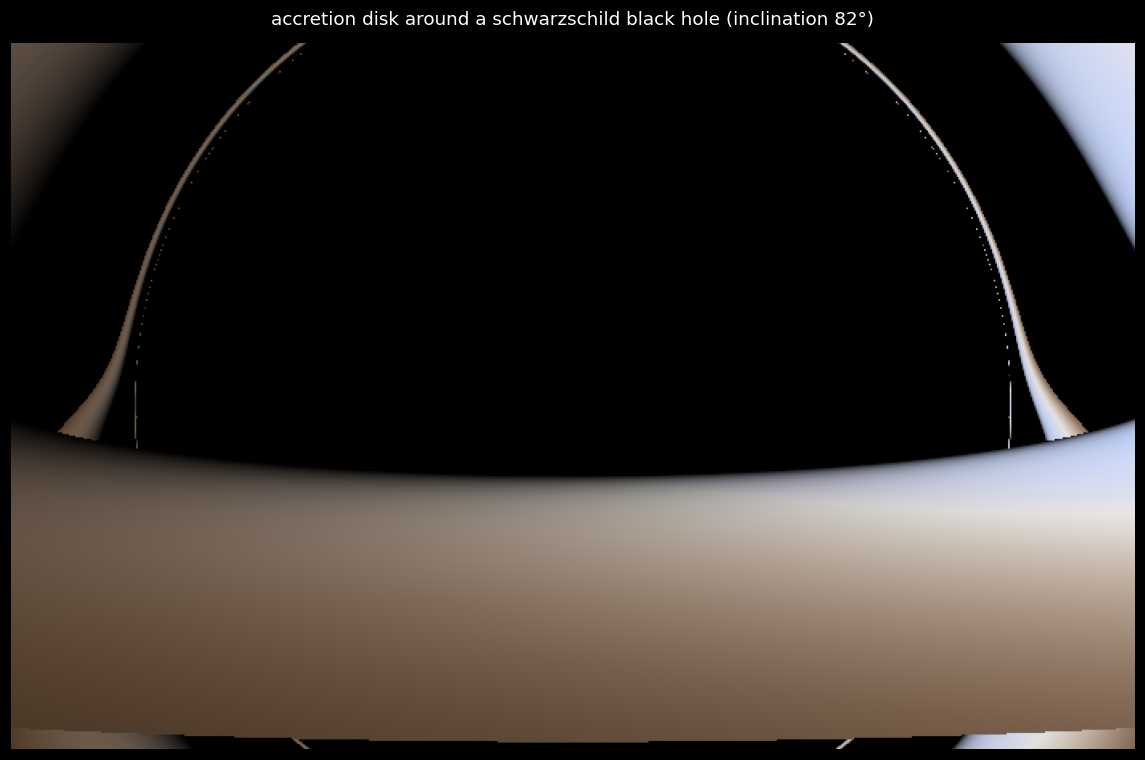

In [7]:
W, H = 700, 440
t0 = time.time()
cam, dirs = camera_rays(W, H, r_cam=45, incl_deg=82, fov_deg=17)
hit_r, Lz = trace(cam, dirs)
img, g_fac, hit_mask = shade(hit_r, Lz, (H, W))
print(f"traced {W*H:,} geodesics in {time.time()-t0:.1f} s - "
      f"{100*(~np.isnan(hit_r)).mean():.1f}% hit the disk")

plt.figure(figsize=(11, 7), facecolor='black')
plt.imshow(img, origin='lower')
plt.axis('off')
plt.title("accretion disk around a schwarzschild black hole (inclination 82°)",
          color='white', pad=12)
plt.tight_layout(); plt.show()

AHHHHHHHHHHHHHHHHHH SHE'S SO PRETTY

with ONE single differential equation btw

remember, the disk is physically just a flat glowing ring, like a vinyl record. everything strange about this picture is spacetime bending the light on its way to us. the anatomy of our black hole is,m

* <b>the upper arc</b> is the far side of the disk. it's physically hidden behind the black hole but its light gets bent over the top into our line of sight. we are seeing behind the hole
* <b>the lower arc</b> is the far side's underside bent under the shadow. yes, we see the same hidden gas twice, from two directions at once
* <b>the thin bright ring</b> hugging the shadow is the photon ring light that circled the hole near the photon sphere at $3M$ (the pencil on its tip, briefly balanced) before escaping to us
* <b>the left/right asymmetry</b> is the $g^4$ beaming the left side races toward us and gets the headlight boost
* <b>the black disk</b> is the shadow, and chapter one's homework pays off here: its apparent radius is $b_c = 3\sqrt3\,M \approx 5.2M$, not $2M$. the hole casts a shadow bigger than its body

and this is the image kip thorne's team built (with vastly more sophistication) for interstellar, and the lopsided ring the event horizon telescope photographed around m87*

everything above came from watching nearly edge on. but how much of that drama is the disk, and how much is the view we chose? let's move around.

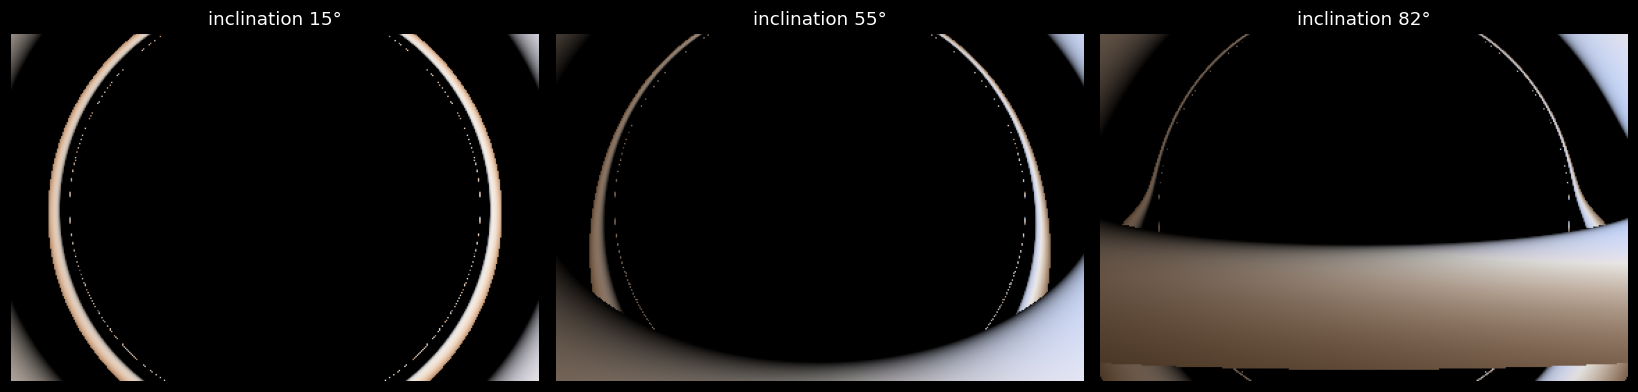

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), facecolor='black')
for ax, incl in zip(axes, [15, 55, 82]):
    cam_i, dirs_i = camera_rays(380, 250, incl_deg=incl)
    h, L = trace(cam_i, dirs_i)
    im, *_ = shade(h, L, (250, 380))
    ax.imshow(im, origin='lower'); ax.axis('off')
    ax.set_title(f"inclination {incl}°", color='white')
plt.tight_layout(); plt.show()

from the balcony (left), the disk is a calm, honest ring you'd barely suspect anything relativistic is going on. from the front row (right), lensing folds the hidden far side into arcs above and below the shadow, and the whole "hat and ring" costume appears.

the disk never changes. only our line of sight through the curvature does.

one more diagnostic: instead of brightness, paint every pixel with its $g$-factor directly. blue means blueshifted ($g > 1$), red means redshifted ($g < 1$). this cleanly separates the two effects fighting over every photon doppler shift from the orbital motion and gravity's redshift from the depth of the well.

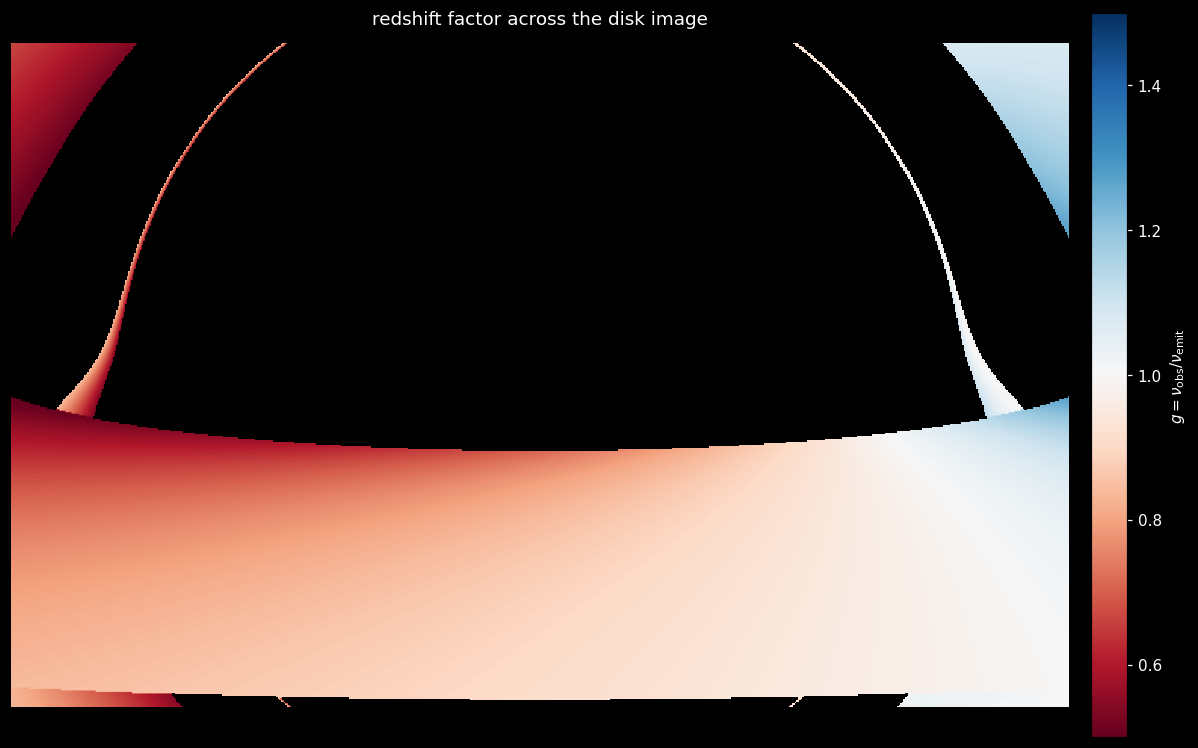

In [9]:
gmap = np.full(W * H, np.nan)
gmap[hit_mask] = g_fac
gmap = gmap.reshape(H, W)

plt.figure(figsize=(11, 7), facecolor='black')
pc = plt.imshow(gmap, origin='lower', cmap='RdBu', vmin=0.5, vmax=1.5)
plt.axis('off')
cb = plt.colorbar(pc, fraction=0.04, pad=0.02)
cb.set_label(r"$g = \nu_{\rm obs}/\nu_{\rm emit}$", color='white')
cb.ax.yaxis.set_tick_params(color='white'); plt.setp(cb.ax.get_yticklabels(), color='white')
plt.title("redshift factor across the disk image", color='white', pad=12)
plt.tight_layout(); plt.show()

the approaching side wins its fight with gravity and doppler blueshift beats the redshift and the light arrives bluer than it left. everywhere else, gravity collects its toll, hardest at the inner edge where the well is deepest.

astronomers use exactly this: the smeared, skewed shape of iron emission lines from real disks is this map integrated. the shape of a spectral line, measured from earth, tells you how deep the disk reaches and therefore (as chapter two hinted) how fast the hole spins.

in this chapter, we learnt that a black hole is invisible, but its dinner is not. matter can't fall straight in, it spirals, flattens into a disk and friction turns orbital energy into heat and light, brightest just outside the last parking spot and silent beyond it. then spacetime itself plays projectionist, folding the hidden far side of the disk into arcs, wrapping a photon ring around a shadow 2.6× wider than the horizon and boosting the approaching side with the $g^4$ headlight.


how efficient is this machine? matter spiralling into a schwarzschild hole radiates away about 6% of its rest mass energy, $E = mc^2$, cashed out as light before crossing the horizon. around a fast spinning kerr hole, up to an absurd 42%. for comparison, nuclear fusion, the process powering every star in the sky manages about 0.7%.

feed a black hole one sun's worth of gas per year and it outshines its entire host galaxy. we call those quasars and they are visible across most of the observable universe.

> the brightest things in the universe are things falling into the darkest ones.

what a beautiful idea!

see you in chapter four :3